In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cfe.data import FateAnnData
from cfe.metric.metric_correlation_v2 import calculate_correlation
from cfe.metric.metric_position_predict_v3 import calculate_position_predict
from cfe.metric.metric_featureimp_v3 import (
    calculate_overall_feature_importance,
    calculate_featureimp_cor,
    calculate_featureimp_enrichment,
    fi_ranger_rf_tiny,
    fi_ranger_rf_lite
)
from cfe.metric.cluster_metric_v2 import calculate_mapping_branches, calculate_mapping_milestones,calculate_mapping
from cfe.metric._topology_metric.metric_him import calculate_him
from cfe.metric.topology_metric import calc_isomorphic, calculate_edge_flip
import matplotlib.pyplot as plt
import seaborn as sns

[2025年04月27日 16时58分06秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
cluster_key = "clusters"

fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
fadata.layers['expression'].toarray()[:20, :20]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 2., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 2.,
        0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0.

In [5]:
# Normalization
# Normalizing to median total counts
sc.pp.normalize_total(fadata)
# Logarithmize the data
sc.pp.log1p(fadata)

# Feature selection
sc.pp.highly_variable_genes(fadata, n_top_genes=2000)
fadata = fadata[:, fadata.var.highly_variable]
fadata

[2025年04月27日 16时58分18秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 2001
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [ ]:
fadata.X.toarray()[:20, :20]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 923267 stored elements and shape (3696, 2000)>

In [3]:
# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

[2025年04月26日 22时23分15秒] DEBUG    FateAnnData add_trajectory                                                  


[2025年04月26日 22时23分58秒] DEBUG    plot_trajectory                                                             
[2025年04月26日 22时24分07秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年04月26日 22时24分09秒] DEBUG    add waypoints shape is (212, 3696), finished!                               


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

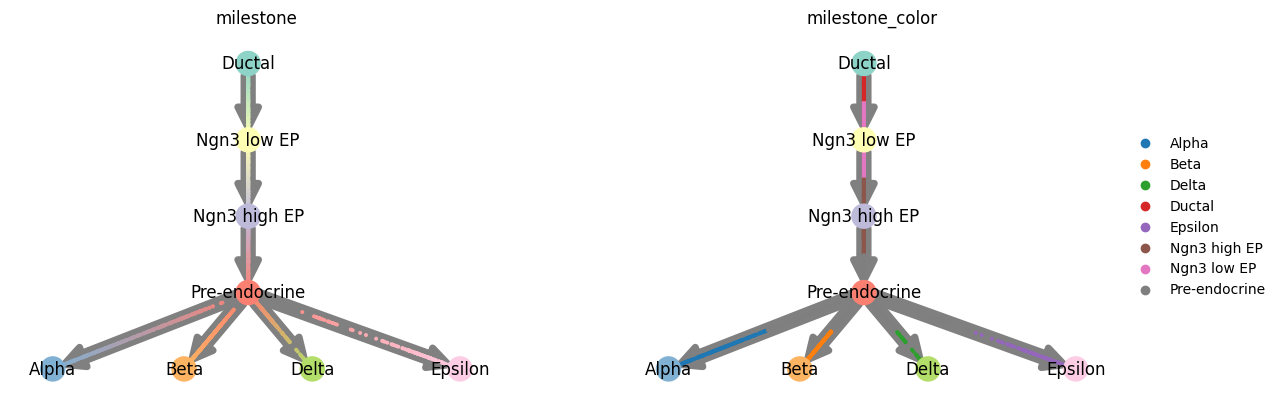

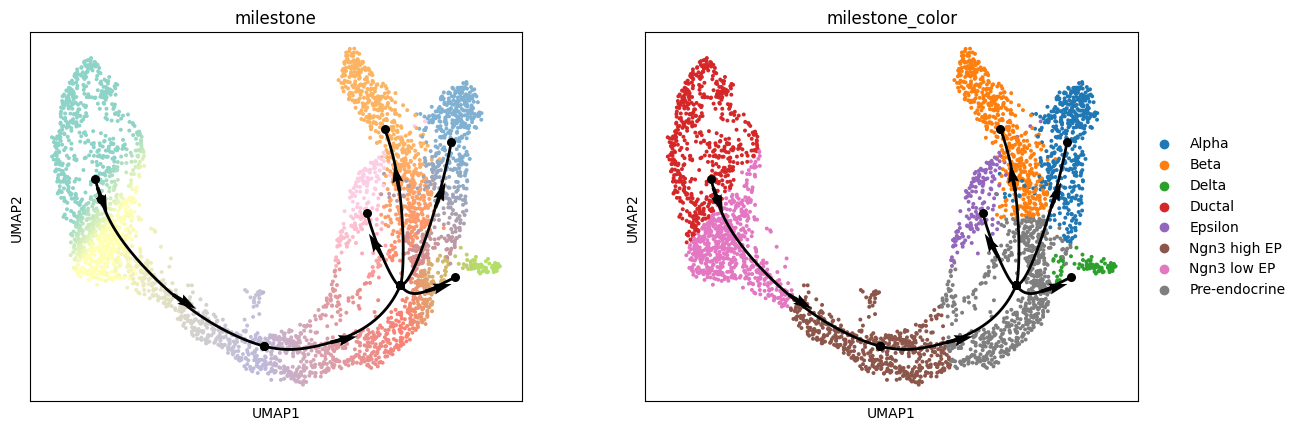

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color
cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

In [5]:
prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

In [6]:
method_name_list = ["comp1", "state_comp","paga","cluster_mst","projection_mst"]
for method_name in method_name_list:
        method = cfe.method.FateMethod(method_name=method_name)
        method.infer_trajectory(fadata)

[2025年04月26日 22时24分34秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x79fc8152f9a0> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x79fc5309a440>                                                                   
[2025年04月26日 22时24分35秒] DEBUG    FateAnnData add_trajectory                                                  
                        DEBUG    FunctionBackend __init__                                                          
                        INFO     Loaded function: <function cf_state_comp at 0x79fc78bff7f0> from                  
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function

In [7]:
parsed_model_name_list = fadata.get_all_model_name() # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年04月26日 22时24分48秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'comp1-python_function',
  'state_comp-python_function',
  'paga-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function'],
 ['ref',
  '20250426_222434__comp1-python_function__tBN2NuxDgg',
  '20250426_222435__state_comp-python_function__5MhFi0ceoq',
  '20250426_222436__paga-python_function__qaUScC1ROR',
  '20250426_222440__cluster_mst-python_function__a5m1tYxLZX',
  '20250426_222441__projection_mst-python_function__2bSO7zG7jY'])

In [ ]:
new_fadata = cfe.data.FateAnnData(
        X=fadata.X,
        obs=fadata.obs,
        uns=fadata.uns
    )
for i in model_name_list: 
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]['milestone_wrapper']
    new_fadata.add_waypoints()
    # 使用单引号避免冲突
    # print(f"{i}'s milestone_network is:\n {new_fadata.milestone_wrapper['milestone_network']}")
    # print(f"{i}'s progressions is:\n {new_fadata.milestone_wrapper['progressions']}")

    

prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

[2025年04月26日 22时25分02秒] DEBUG    FateAnnData add_waypoints                                                   
ref's milestone_network is:
             from             to    length  directed
0         Ductal    Ngn3 low EP  1.550870      True
1    Ngn3 low EP   Ngn3 high EP  8.271646      True
2   Ngn3 high EP  Pre-endocrine  7.109470      True
3  Pre-endocrine          Alpha  5.915155      True
4  Pre-endocrine           Beta  5.538605      True
5  Pre-endocrine          Delta  4.209592      True
6  Pre-endocrine        Epsilon  3.827837      True
ref's progressions is:
        cell_id           from             to  percentage
0     cell_000  Pre-endocrine          Alpha    0.440591
1     cell_021  Pre-endocrine        Epsilon    0.632816
2     cell_023  Pre-endocrine          Delta    0.445354
3     cell_033  Pre-endocrine          Alpha    0.267884
4     cell_034   Ngn3 high EP  Pre-endocrine    0.926867
..         ...            ...            ...         ...
137  cell_3593  Pre-en

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone', '_cfe_nm_group', '_cfe_te_group'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'

In [ ]:
new_fadata.prior_information

{'start_id': 'cell_000',
 'groups_id': ['Pre-endocrine',
  'Ngn3 low EP',
  'Alpha',
  'Ductal',
  'Pre-endocrine',
  'Ductal',
  'Alpha',
  'Ductal',
  'Ductal',
  'Ngn3 low EP',
  'Delta',
  'Ductal',
  'Beta',
  'Ductal',
  'Ductal',
  'Ngn3 low EP',
  'Beta',
  'Alpha',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Ngn3 low EP',
  'Epsilon',
  'Beta',
  'Pre-endocrine',
  'Alpha',
  'Alpha',
  'Beta',
  'Beta',
  'Ngn3 low EP',
  'Beta',
  'Ductal',
  'Ngn3 low EP',
  'Alpha',
  'Pre-endocrine',
  'Pre-endocrine',
  'Ductal',
  'Ductal',
  'Beta',
  'Pre-endocrine',
  'Alpha',
  'Beta',
  'Ductal',
  'Alpha',
  'Beta',
  'Beta',
  'Alpha',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Alpha',
  'Epsilon',
  'Alpha',
  'Alpha',
  'Ductal',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Alpha',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Ductal',
  'Pre-endocrine',
  'Ngn3 high EP',
  'Epsilon',
  'Ngn3 high EP',
  'Beta',
  'Pre-endocrine',
  'Ngn3 high EP',
  'Pre-endoc

开始指标部分的分析

In [9]:
metrics = cfe.metric.metrics
metrics

,metric_id,plotmath,latex,html,long_name,category,type,perfect,worst,symmetric
0,correlation,cor[dist],\mathit{cor}_{\textrm{dist}},cor<sub>dist</sub>,Geodesic distance correlation,cell positions,specific,1,0.0,True
1,rf_mse,MSE[rf],\mathit{MSE}_{\textit{rf}},MSE<sub>rf</sub>,Random Forest MSE,neighbourhood,specific,0,0.3,False
2,rf_nmse,NMSE[rf],\mathit{NMSE}_{\textit{rf}},NMSE<sub>rf</sub>,Random Forest Normalised MSE,neighbourhood,specific,1,0.0,False
3,rf_rsq,R[rf]^2,R^{2}_{rf},R<sup>2</sup><sub>rf</sub>,Random Forest R²,neighbourhood,specific,1,0.0,False
4,lm_nmse,NMSE[lm],\mathit{NMSE}_{\textit{lm}},NMSE<sub>lm</sub>,Linear regression Normalised MSE,neighbourhood,specific,1,0.0,False
5,lm_mse,MSE[lm],\mathit{MSE}_{\textit{lm}},MSE<sub>lm</sub>,Linear regression MSE,neighbourhood,specific,0,0.3,False
6,lm_rsq,R[lm]^2,R^{2}_{lm},R<sup>2</sup><sub>lm</sub>,Linear regression R²,neighbourhood,specific,1,0.0,False
7,edge_flip,edgeflip,\textrm{edgeflip},edgeflip,Edge flip,topology,specific,1,0.0,True
8,him,HIM,\textrm{HIM},HIM,Hamming-Ipsen-Mikhailov similarity,topology,specific,1,0.0,True
9,isomorphic,isomorphic,\textrm{isomorphic},Isomorphic,isomorphic,topology,specific,1,0.0,True


拓扑部分

In [ ]:
# metric_topology_dict = {}
# metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
# for model_name in model_name_list:
#     model_metric = cfe.metric.calculate_metrics(
#         fadata,
#         metrics=metric_id_list,
#         now_model=model_name,
#         ref_model="ref"
#     )
#     metric_topology_dict[model_name] = model_metric

# df = pd.DataFrame(metric_topology_dict).T
# df.index=parsed_model_name_list
# df

,isomorphic,edge_flip,him
ref,1.0,1.0,1.000000
comp1-python_function,0.0,0.0,0.267002
state_comp-python_function,0.0,0.4,0.205989
paga-python_function,0.0,0.0,0.588666
cluster_mst-python_function,0.0,0.5,0.809910
projection_mst-python_function,0.0,0.5,0.818616


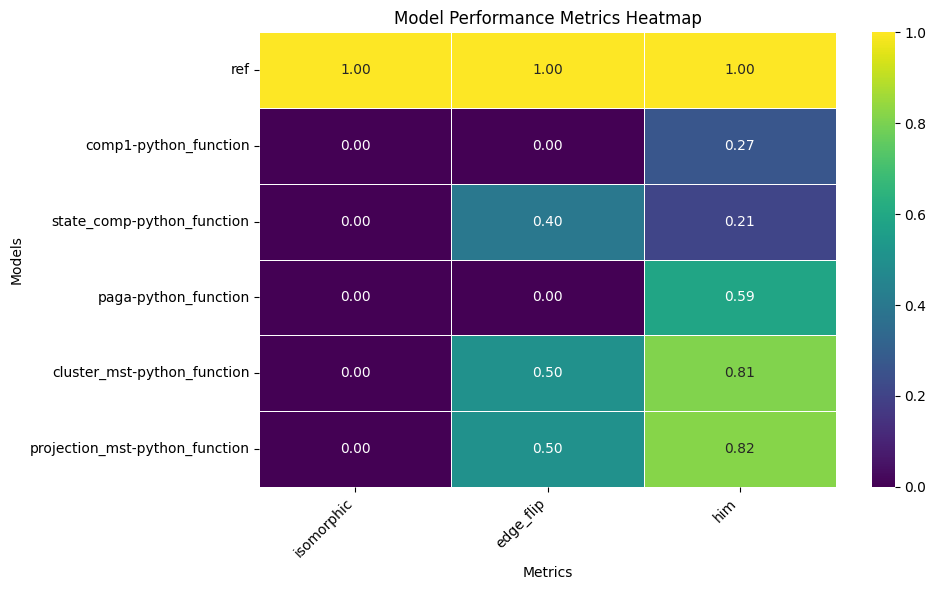

In [ ]:
# #可视化指标
# plt.figure(figsize=(10, 6))
# # 创建热力图
# ax = sns.heatmap(
#     df,
#     annot=True,          # 显示数值
#     fmt=".2f",          # 数值格式（保留2位小数）
#     cmap="viridis",      # 颜色方案
#     linewidths=0.5,     # 单元格边线宽度
#     linecolor="white",  # 单元格边线颜色
#     vmin=0,             # 颜色范围最小值
#     vmax=1              # 颜色范围最大值
# )

# # 调整坐标标签
# plt.xticks(rotation=45, ha="right")  # 旋转列标签
# plt.yticks(rotation=0)               # 保持行标签水平
# plt.xlabel("Metrics")                # x轴标签
# plt.ylabel("Models")                 # y轴标签
# plt.title("Model Performance Metrics Heatmap")  # 标题

# # 显示图形
# plt.tight_layout()
# plt.show()

查看correlation表现

In [ ]:
# metric_correlation_dict = {}
# metric_id_list = metrics[metrics["category"] == "cell positions"]["metric_id"].tolist()
# for model_name in model_name_list:
#     model_metric = cfe.metric.calculate_metrics(
#         fadata,
#         metrics=metric_id_list,
#         now_model=model_name,
#         ref_model="ref"
#     )
#     metric_correlation_dict[model_name] = model_metric

# df = pd.DataFrame(metric_correlation_dict).T
# df.index=parsed_model_name_list
# df

,correlation
ref,1.000000
comp1-python_function,0.252029
state_comp-python_function,0.000000
paga-python_function,0.121869
cluster_mst-python_function,0.000000
projection_mst-python_function,0.000000


查看各个F1 score的表现

In [ ]:
# #映射到里程碑上
# F1_dict={}
# for i,j in zip(model_name_list,parsed_model_name_list):
#     F1_dict[j]=calculate_mapping(new_fadata,grouping='branches',simplify=True,ref_model= "ref",pred_model= i)

# df = pd.DataFrame.from_dict(F1_dict, orient='index')
#df

,recovery,relevance,F1
ref,1.000000,1.000000,1.000000
comp1-python_function,0.142857,0.279221,0.189011
state_comp-python_function,0.160936,0.283260,0.205255
paga-python_function,0.452052,0.506247,0.477617
cluster_mst-python_function,0.607434,0.660061,0.632655
projection_mst-python_function,0.351638,0.342015,0.346760


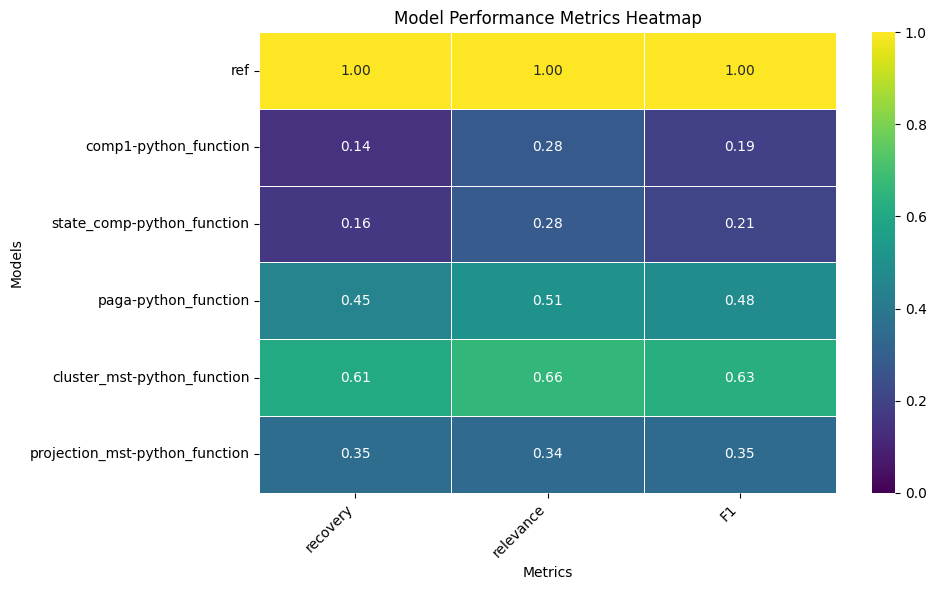

In [ ]:
# #可视化指标
# plt.figure(figsize=(10, 6))
# # 创建热力图
# ax = sns.heatmap(
#     df,
#     annot=True,          # 显示数值
#     fmt=".2f",          # 数值格式（保留2位小数）
#     cmap="viridis",      # 颜色方案
#     linewidths=0.5,     # 单元格边线宽度
#     linecolor="white",  # 单元格边线颜色
#     vmin=0,             # 颜色范围最小值
#     vmax=1              # 颜色范围最大值
# )

# # 调整坐标标签
# plt.xticks(rotation=45, ha="right")  # 旋转列标签
# plt.yticks(rotation=0)               # 保持行标签水平
# plt.xlabel("Metrics")                # x轴标签
# plt.ylabel("Models")                 # y轴标签
# plt.title("Model Performance Metrics Heatmap")  # 标题

# # 显示图形
# plt.tight_layout()
# plt.show()

试试position_predict相关指标的表现

In [20]:
parsed_model_name_list

['ref',
 'comp1-python_function',
 'state_comp-python_function',
 'paga-python_function',
 'cluster_mst-python_function',
 'projection_mst-python_function']

In [ ]:
# position_predict_dict={}
# for i,j in zip(model_name_list,parsed_model_name_list):
#     position_predict_dict[j]=calculate_position_predict(
#         new_fadata,
#         ref_model='ref',
#         pred_model=i,
#         metrics=["rf_mse","rf_rsq","rf_nmse","lm_mse","lm_rsq","lm_nmse"]
#     )['summary']

# position_predict_dict

{'ref': {'rf_mse': 5.590169441778354e-07,
  'rf_rsq': 0.999988888281096,
  'rf_nmse': 0.9999929852434435,
  'lm_mse': 0.0,
  'lm_rsq': 1.0,
  'lm_nmse': 1.0},
 'comp1-python_function': {'rf_mse': 0.06528748055817059,
  'rf_rsq': 0.17887208655178893,
  'rf_nmse': 0.18074794141170825,
  'lm_mse': 0.0687666591467015,
  'lm_rsq': 0.10755884936251232,
  'lm_nmse': 0.13708988941641576},
 'state_comp-python_function': {'rf_mse': 0.04719585101256867,
  'rf_rsq': 0.39272715502972727,
  'rf_nmse': 0.4077685680576577,
  'lm_mse': 0.0646178322517662,
  'lm_rsq': 0.15571539451207966,
  'lm_nmse': 0.18915094224527762},
 'paga-python_function': {'rf_mse': 0.02109767745982765,
  'rf_rsq': 0.6148196216040158,
  'rf_nmse': 0.7352583444387102,
  'lm_mse': 0.03298106059213679,
  'lm_rsq': 0.4960700600343282,
  'lm_nmse': 0.5861411475289073},
 'cluster_mst-python_function': {'rf_mse': 0.0075560555126889814,
  'rf_rsq': 0.8969294129763882,
  'rf_nmse': 0.905183750687663,
  'lm_mse': 0.007556725252544033,
  

In [ ]:
# df = pd.DataFrame.from_dict(position_predict_dict, orient='index')
# df

,rf_mse,rf_rsq,rf_nmse,lm_mse,lm_rsq,lm_nmse
ref,5.590169e-07,0.999989,0.999993,0.000000,1.000000,1.000000
comp1-python_function,6.528748e-02,0.178872,0.180748,0.068767,0.107559,0.137090
state_comp-python_function,4.719585e-02,0.392727,0.407769,0.064618,0.155715,0.189151
paga-python_function,2.109768e-02,0.614820,0.735258,0.032981,0.496070,0.586141
cluster_mst-python_function,7.556056e-03,0.896929,0.905184,0.007557,0.896922,0.905175
projection_mst-python_function,4.835415e-02,0.373534,0.393234,0.038117,0.490294,0.521693


In [ ]:
#print(df)

                                      rf_mse    rf_rsq   rf_nmse    lm_mse  \
ref                             5.590169e-07  0.999989  0.999993  0.000000   
comp1-python_function           6.528748e-02  0.178872  0.180748  0.068767   
state_comp-python_function      4.719585e-02  0.392727  0.407769  0.064618   
paga-python_function            2.109768e-02  0.614820  0.735258  0.032981   
cluster_mst-python_function     7.556056e-03  0.896929  0.905184  0.007557   
projection_mst-python_function  4.835415e-02  0.373534  0.393234  0.038117   

                                  lm_rsq   lm_nmse  
ref                             1.000000  1.000000  
comp1-python_function           0.107559  0.137090  
state_comp-python_function      0.155715  0.189151  
paga-python_function            0.496070  0.586141  
cluster_mst-python_function     0.896922  0.905175  
projection_mst-python_function  0.490294  0.521693  


计算cor和wcor相关的表现(这里利用fadata，因为new_fadata在表达矩阵上可能存在问题)

In [36]:
featureimp_dict={}
for i,j in zip(model_name_list,parsed_model_name_list):
    featureimp_dict[j]=calculate_featureimp_cor(
            fadata,
            "ref",
            i,
            'expression',
            fi_ranger_rf_tiny()
    )

featureimp_dict

{'ref': {'featureimp_cor': 1.0, 'featureimp_wcor': 1.0},
 'comp1-python_function': {'featureimp_cor': 0.7435355637675803,
  'featureimp_wcor': 0.8701372962835766},
 'state_comp-python_function': {'featureimp_cor': 0.7844083983081116,
  'featureimp_wcor': 0.8893175834668549},
 'paga-python_function': {'featureimp_cor': 0.8816817024598862,
  'featureimp_wcor': 0.941919647460469},
 'cluster_mst-python_function': {'featureimp_cor': 0.9265364787513712,
  'featureimp_wcor': 0.9623716238032111},
 'projection_mst-python_function': {'featureimp_cor': 0.8720130586438453,
  'featureimp_wcor': 0.9242839781818463}}

In [29]:
df = pd.DataFrame.from_dict(featureimp_dict, orient='index')
df

,featureimp_cor,featureimp_wcor
ref,1.000000,1.000000
comp1-python_function,0.743536,0.870137
state_comp-python_function,0.784408,0.889318
paga-python_function,0.881682,0.941920
cluster_mst-python_function,0.926536,0.962372
projection_mst-python_function,0.872013,0.924284
